<a href="https://colab.research.google.com/github/Ilannahaimenis19/Data-science_Exercises/blob/main/Regressores_2_Housing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadbinimran/housing-price-prediction-data")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path, 'housing_price_dataset.csv'))

display(df)

Path to dataset files: /kaggle/input/housing-price-prediction-data


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065
...,...,...,...,...,...,...
49995,1282,5,3,Rural,1975,100080.865895
49996,2854,2,2,Suburb,1988,374507.656727
49997,2979,5,3,Suburb,1962,384110.555590
49998,2596,5,2,Rural,1984,380512.685957


Dimensões: (50000, 6)

Tipos e nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB
None


,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


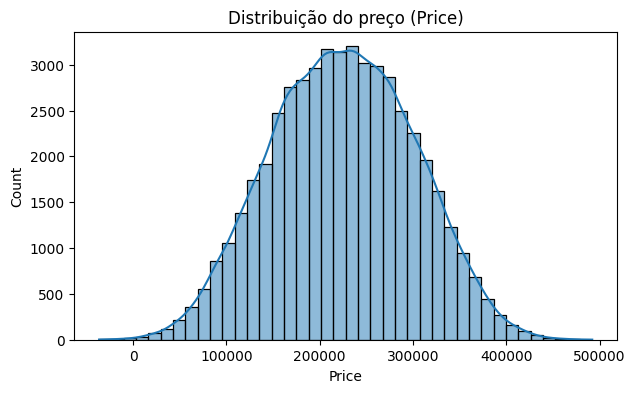

In [75]:
print("Dimensões:", df.shape)
print("\nTipos e nulos:")
print(df.info())

display(df.describe())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.histplot(df["Price"], bins=40, kde=True)
plt.title("Distribuição do preço (Price)")
plt.show()


In [76]:
df_prep = df.copy()

# 1. Remover preços negativos
df_prep = df_prep[df_prep["Price"] > 0].reset_index(drop=True)

# 2. Criar feature Age
current_year = 2024
df_prep["Age"] = current_year - df_prep["YearBuilt"]

# 3. One-hot encoding para Neighborhood
df_prep = pd.get_dummies(df_prep, columns=["Neighborhood"], drop_first=True)
df_prep[df_prep.select_dtypes('bool').columns] = df_prep.select_dtypes('bool').astype(int)


print("Dimensões após limpeza:", df_prep.shape)
print("Nulos por coluna:\n", df_prep.isna().sum())

display(df_prep.head())

Dimensões após limpeza: (49978, 8)
Nulos por coluna:
 SquareFeet             0
Bedrooms               0
Bathrooms              0
YearBuilt              0
Price                  0
Age                    0
Neighborhood_Suburb    0
Neighborhood_Urban     0
dtype: int64


,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Age,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,215355.283618,55,0,0
1,2459,3,2,1980,195014.221626,44,0,0
2,1860,2,1,1970,306891.012076,54,1,0
3,2294,2,1,1996,206786.787153,28,0,1
4,2130,5,2,2001,272436.239065,23,1,0


In [77]:
from sklearn.preprocessing import MinMaxScaler

# separa numéricas e categóricas
num_cols = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Age']
cat_cols = ['Neighborhood_Suburb', 'Neighborhood_Urban']

# normaliza apenas numéricas
scaler = MinMaxScaler()
X_num = scaler.fit_transform(df_prep[num_cols])
X_num = pd.DataFrame(X_num, columns=num_cols)

# junta numéricas normalizadas + categóricas originais
X = pd.concat([X_num, df_prep[cat_cols].reset_index(drop=True)], axis=1)

y = df_prep['Price']

display(X.head())

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Age,Neighborhood_Suburb,Neighborhood_Urban
0,0.563282,0.666667,0.0,0.267606,0.732394,0,0
1,0.729865,0.333333,0.5,0.422535,0.577465,0,0
2,0.430215,0.000000,0.0,0.281690,0.718310,1,0
3,0.647324,0.000000,0.0,0.647887,0.352113,0,1
4,0.565283,1.000000,0.5,0.718310,0.281690,1,0


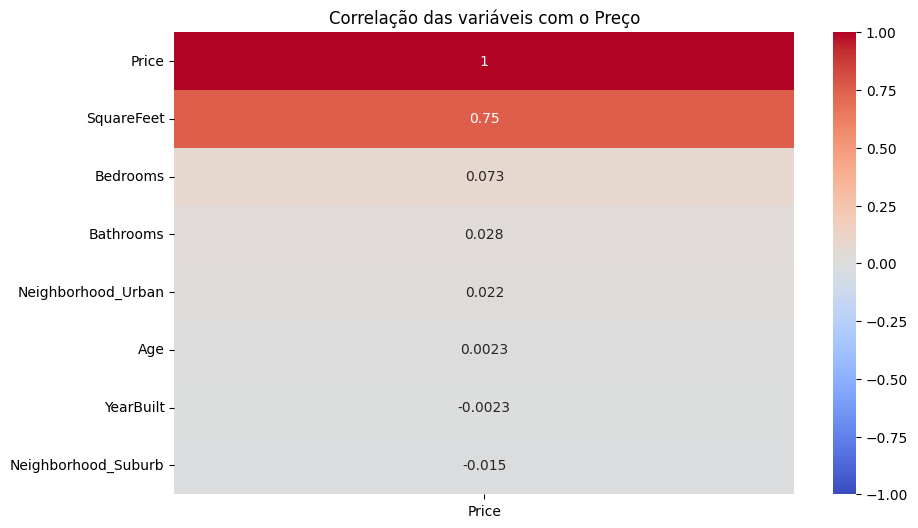

In [78]:
# Selecionar apenas variáveis numéricas
corr = df_prep.corr(numeric_only=True)

# Plotar mapa de calor de correlação
plt.figure(figsize=(10,6))
sns.heatmap(corr[['Price']].sort_values(by='Price', ascending=False),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação das variáveis com o Preço")
plt.show()

In [79]:
from sklearn.model_selection import train_test_split

# separar 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste :", X_test.shape)

Tamanho treino: (39982, 7)
Tamanho teste : (9996, 7)


# Linear Regression

Resultados – Linear Regression
RMSE: 49439.61665255519
R²: 0.5779866236606085


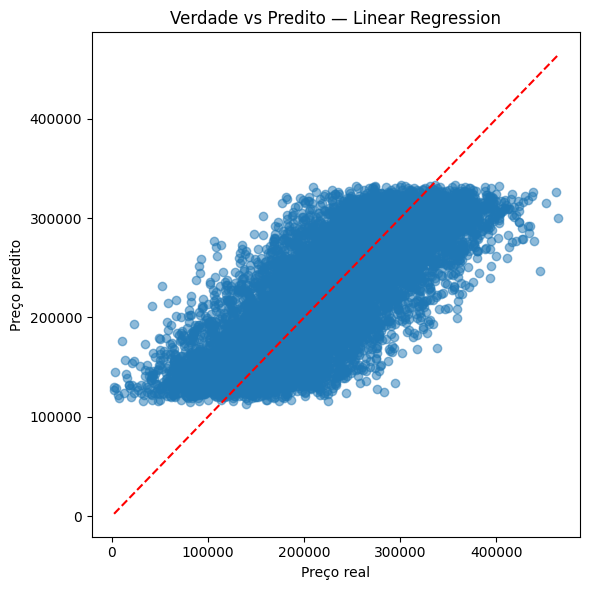

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# instanciar e treinar
lr = LinearRegression()
lr.fit(X_train, y_train)

# prever
y_pred_lr = lr.predict(X_test)

# métricas
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Resultados – Linear Regression")
print("RMSE:", rmse)
print("R²:", r2)

# gráfico Verdade vs Predito
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv], [minv, maxv], "--", color="red")
plt.title("Verdade vs Predito — Linear Regression")
plt.xlabel("Preço real")
plt.ylabel("Preço predito")
plt.tight_layout()
plt.show()


# Random Forest Regressor

Resultados – Random Forest
RMSE: 52403.00335936726
R²  : 0.5258798816790968


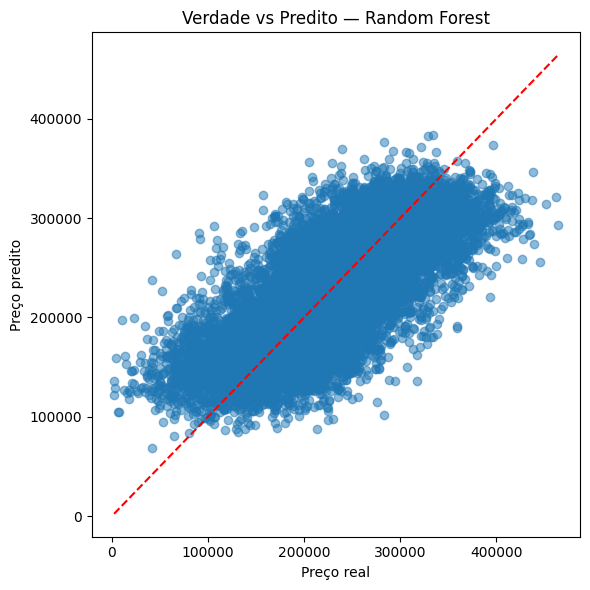

In [81]:
from sklearn.ensemble import RandomForestRegressor

# modelo (parâmetros iniciais sólidos)
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# treinar
rf.fit(X_train, y_train)

# prever
y_pred_rf = rf.predict(X_test)

# métricas
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("Resultados – Random Forest")
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

# gráfico Verdade vs Predito
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv], [minv, maxv], "--", color="red")
plt.title("Verdade vs Predito — Random Forest")
plt.xlabel("Preço real")
plt.ylabel("Preço predito")
plt.tight_layout()
plt.show()

# Support Vector Regressor (SVR)

Resultados – SVR (RBF)
RMSE: 59423.968643624285
R²  : 0.39032367148009917


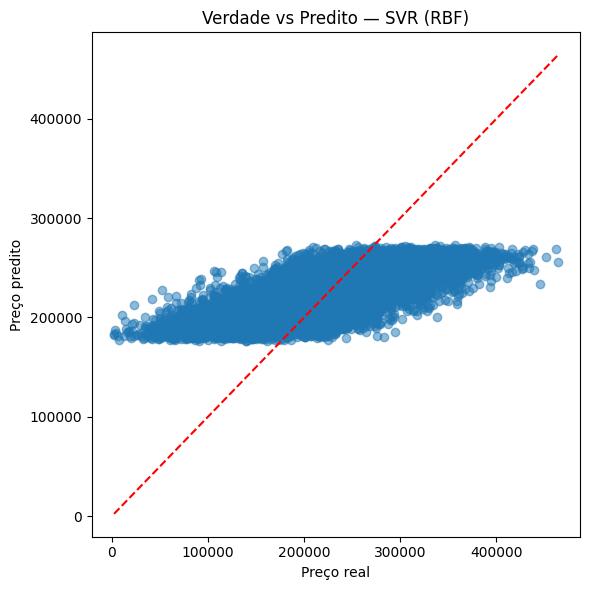

In [82]:
from sklearn.svm import SVR

# SVR precisa de dados normalizados (já estão!)
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr   = r2_score(y_test, y_pred_svr)

print("Resultados – SVR (RBF)")
print("RMSE:", rmse_svr)
print("R²  :", r2_svr)

# Gráfico Verdade vs Predito
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.5)
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv], [minv, maxv], "--", color="red")
plt.title("Verdade vs Predito — SVR (RBF)")
plt.xlabel("Preço real")
plt.ylabel("Preço predito")
plt.tight_layout()
plt.show()

# Gradient Boosting

In [87]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

print("Resultados – Gradient Boosting")
print("RMSE:", rmse_gbr)
print("R²  :", r2_gbr)

Resultados – Gradient Boosting
RMSE: 49469.805380364785
R²  : 0.5774710882473022


# Comparação

,Modelo,RMSE,R²
0,Linear Regression,49439.616653,0.577987
3,Gradient Boosting,49469.805380,0.577471
1,Random Forest,52403.003359,0.525880
2,SVR,59423.968644,0.390324


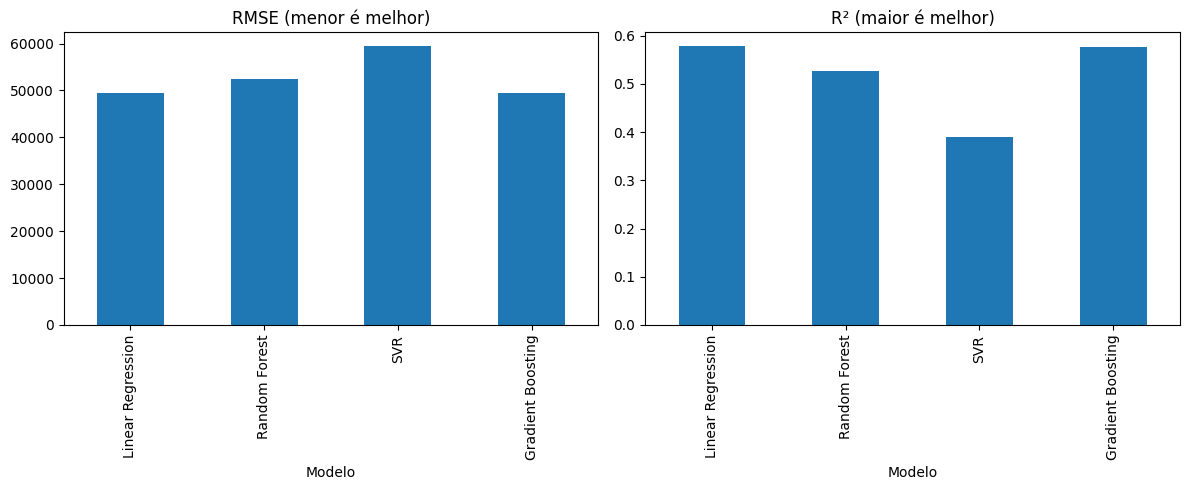

In [88]:
comparacao = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest", "SVR", "Gradient Boosting"],
    "RMSE":   [rmse, rmse_rf, rmse_svr, rmse_gbr],
    "R²":     [r2,   r2_rf,   r2_svr,   r2_gbr]
})
display(comparacao.sort_values("RMSE"))

# Gráficos separados para não confundir
fig, axes = plt.subplots(1, 2, figsize=(12,5))
comparacao.set_index("Modelo")["RMSE"].plot.bar(ax=axes[0], title="RMSE (menor é melhor)")
comparacao.set_index("Modelo")["R²"].plot.bar(ax=axes[1], title="R² (maior é melhor)")
plt.tight_layout()
plt.show()